In [3]:
import pathpyG as pp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
import contextily as cx
import folium

## Visualize streamgague locations

In [4]:
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../data/clean/"))

metadata = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022_metadata_all.csv"))

# --- Create geometry from lat/lon ---
geometry = gpd.points_from_xy(metadata["longitude"], metadata["latitude"])

gdf01 = gpd.GeoDataFrame(metadata, geometry=geometry, crs="EPSG:4326")

gdf = pd.concat([gdf01])

### HTML

In [5]:
# --- Create base map centered on gauges ---
center_lat = gdf["latitude"].mean()
center_lon = gdf["longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8,
    tiles="OpenStreetMap"
)

# --- Add gauge markers for basin 1 ---
fg1 = folium.FeatureGroup(name="Stream gauges 02040101")

for _, row in gdf01.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color="red",
        fill=True,
        fill_color="red",
        popup=f"Site ID: {row['site_id']} \n Site Name: {row['site_name']}"
    ).add_to(fg1)

fg1.add_to(m)

# --- Add layer control ---
folium.LayerControl().add_to(m)

# --- Save interactive HTML map ---
m.save("stream_gauges_map_subbasin.html")

### Static map

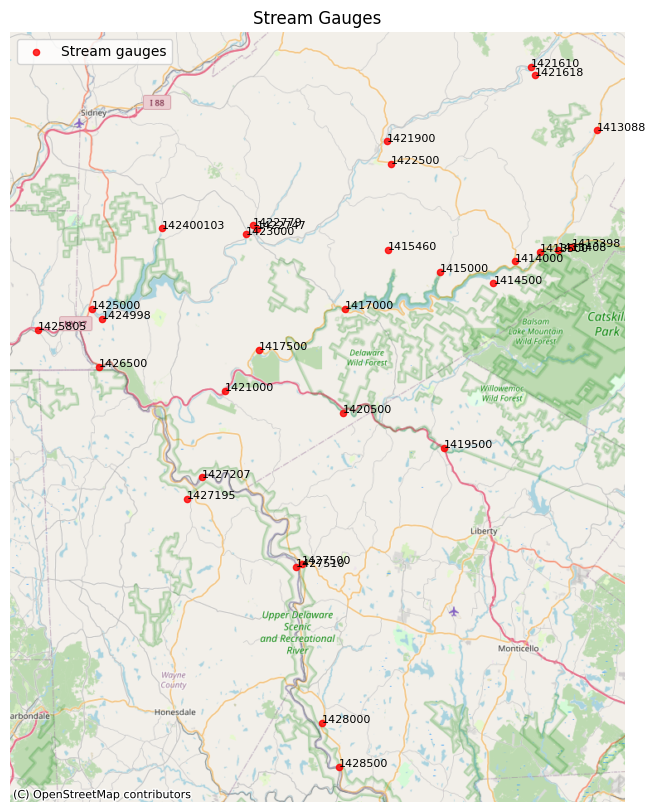

In [6]:

# --- Convert to Web Mercator for basemap ---
gdf = gdf.to_crs(epsg=3857)


# --- Plot ---
fig, ax = plt.subplots(figsize=(10,10))

gdf.plot(
    ax=ax,
    color="red",
    markersize=20,
    alpha=0.8,
    label="Stream gauges"
)

# Add basemap 
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
ax.legend(loc="upper left")
# Add labels
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf["site_id"]):
    ax.text(x, y, str(label),fontsize=8)

plt.title("Stream Gauges")
plt.show()

## Rename sites and create directed graph

In [78]:
# site_dict = {
#     1421610: "site0",
#     1421618: "site1",
#     1421900: "site2",
#     1422500: "site3",
#     1422747: "site4",
#     1422779: "site5",
#     1423000: "site6",
#     142400103: "site7",
#     1424998: "site8",
#     1425000: "site9",
#     1425805: "site10",
#     1426500: "site11",
#     1427195: "site12",
#     1427207: "site13",
#     1427500: "site14",
#     1427510: "site15",
#     1428000: "site16",
#     1428500: "site17",
#     1413088: "site18",
#     1413398: "site19",
#     1413408: "site20",
#     1413500: "site21",
#     1414000: "site22",
#     1414500: "site23",
#     1415000: "site24",
#     1415460: "site25",
#     1417000: "site26",
#     1417500: "site27",
#     1419500: "site28",
#     1420500: "site29",
#     1421000: "site30"
# }

In [7]:
# List of new site names in the order I specified (from upstream > downstream)
site_rename_list = [
    "site0", "site1", "site2", "site3", "site4",
    "site6", "site7", "site9", "site11", "site13",
    "site14", "site15", "site16", "site17", "site5",
    "site10", "site12", "site8",
    "site18", "site19", "site20", "site21", "site22",
    "site23", "site24", "site25", "site26", "site27",
    "site28", "site29", "site30"
]

metadata["site_rename"] = site_rename_list

metadata[['site_id', 'site_name', 'site_rename']]


,site_id,site_name,site_rename
0,1413088,EAST BRANCH DELAWARE RIVER AT ROXBURY NY,site0
1,1413398,BUSH KILL NEAR ARKVILLE NY,site1
2,1413408,DRY BROOK AT ARKVILLE,site2
3,1413500,EAST BRANCH DELAWARE RIVER AT MARGARETVILLE NY,site3
4,1414000,PLATTE KILL AT DUNRAVEN NY,site4
5,1414500,MILL BROOK NEAR DUNRAVEN NY,site6
6,1415000,TREMPER KILL NEAR ANDES NY,site7
7,1415460,TERRY CLOVE KILL NEAR DE LANCEY NY,site9
8,1417000,EAST BRANCH DELAWARE RIVER AT DOWNSVILLE NY,site11
9,1417500,EAST BRANCH DELAWARE RIVER AT HARVARD NY,site13


In [8]:
graph_edges = [("site0", "site2"), 
              ("site1", "site2"),
              ("site2", "site6"),
              ("site3", "site6"),
              ("site4", "site6"),
              ("site5", "site6"),
              ("site6", "site8"), #note site 6 and 7 both flow into the reservoir but from differennt brances
              ("site7", "site8"), #note site 8 is after the reservoir
              ("site8", "site9"),
              ("site9", "site11"),
              ("site10", "site11"),
              ("site11", "site13"),
              ("site12", "site13"),
              ("site13", "site15"),
              ("site14", "site15"),
              ("site15", "site17"),
              ("site16", "site17")] 


graph_edges02 = [("site18", "site21"),
              ("site19", "site20"),
              ("site20", "site21"),
              ("site21", "site26"), # NOTE site 26 is th outlet of the Pepcaton reservoir so all these other sites lead to the reservoir
              ("site22", "site26"),
              ("site23", "site26"),
              ("site24", "site26"),
              ("site25", "site26"),
              ("site26", "site27"),
              ("site27", "site30"),
              ("site28", "site29"),
              ("site29", "site30")]


graph_edges_all = graph_edges + graph_edges02 + [("site30", "site13")] # point of connection between the two subbasins

In [9]:
river_network = pp.Graph.from_edge_list(graph_edges_all)

# Adjacency matrix 
A = river_network.sparse_adj_matrix()
# print(A.todense())

## Not sure why the order of the nodes is different than the order of site 1 etc. so issue coloring
group0 = ("site0", "site1", "site2", "site3", "site4", "site5", "site6", "site7", "site8", "site9", "site10", "site11", "site12", "site13", "site14", "site15", "site16", "site17")
group1 = ("site18", "site19", "site20", "site21", "site22", "site23", "site24", "site25", "site26", "site27", "site28", "site29", "site30")
z= []
for i, node in enumerate(river_network.nodes):
    if node in group0:
        z.append(0)
    elif node in group1:
        z.append(1)
# z = np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1])

colors = {0: 'red', 1: 'blue'}
pp.plot(river_network, node_color = [colors[z[river_network.mapping.to_idx(x)]] for x in river_network.nodes], node_label = [x for x in river_network.mapping.node_ids]);

## Adding attributes to nodes

note: All `Node` attributes must be prefixed with `node_`. Just like nodes, `Edge` objects can store arbitrary attributes that we can add as a tensor. The name of the attribute must be prefixed by `edge_`.

### Compute summary statistics

In [10]:
precipitation = pd.read_csv(os.path.join(DATA_DIR, "precipitation_wy2022.csv"))

In [ ]:
streamflow = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022.csv"))
precipitation = pd.read_csv(os.path.join(DATA_DIR, "precipitation_wy2022.csv"))

mean_streamflow ={}
std_streamflow = {}
mean_precipitation = {}
std_precipitation = {}

for column in streamflow.columns:
    if column != 'date':
        gauge_name = metadata_01[metadata_01['site_id'] == column]['site_rename'].values[0] if column in metadata_01['site_id'].values else metadata_02[metadata_02['site_id'] == column]['site_rename'].values[0]
        mean_streamflow[gauge_name] = streamflow[column].mean()
        std_streamflow[gauge_name] = streamflow[column].std()

# for column in precipitation.columns:
#     if column != 'date':
#         gauge_name = metadata_01[metadata_01['site_rename'] == column]['site_name'].values[0] if column in metadata_01['site_rename'].values else metadata_02[metadata_02['site_rename'] == column]['site_name'].values[0]
#         rain_days = precipitation[precipitation[column] > 0][column]
#         mean_precipitation[gauge_name] = precipitation[column].mean()
#         std_precipitation[gauge_name] = precipitation[column].std()

NameError: name 'metadata_01' is not defined

In [ ]:
import torch
river_network.data.node_avgprecip = torch.tensor(mean_precipitation)